Read MRF data

In [54]:
import scipy.io as sio
import os
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np


In [55]:
data_location = '/scratch/git/eecs504-project/data/'
parent_folder = data_location + 'MRXCAT/2CH_slice7/'

In [56]:
# Colormaps for T1 and T2 images
X = sio.loadmat(('colormaps_new.mat'))
T1colormap = X['T1colormap']
T2colormap = X['T2colormap']
t1_display = [0, 2500]  # milliseconds
m0_display = [0, 1]     # a.u.
t2_display = [0, 150]   # milliseconds
T1cm = ListedColormap(T1colormap)
T2cm = ListedColormap(T2colormap)

In [57]:
# Read DIP maps
X = sio.loadmat(os.path.join(parent_folder, 'DIP_Dropout10_100Epochs_test_1.mat'))
T1Net = X['T1Net']
T2Net = X['T2Net']
M0Net = X['M0Net']
imNet = X['imNet']

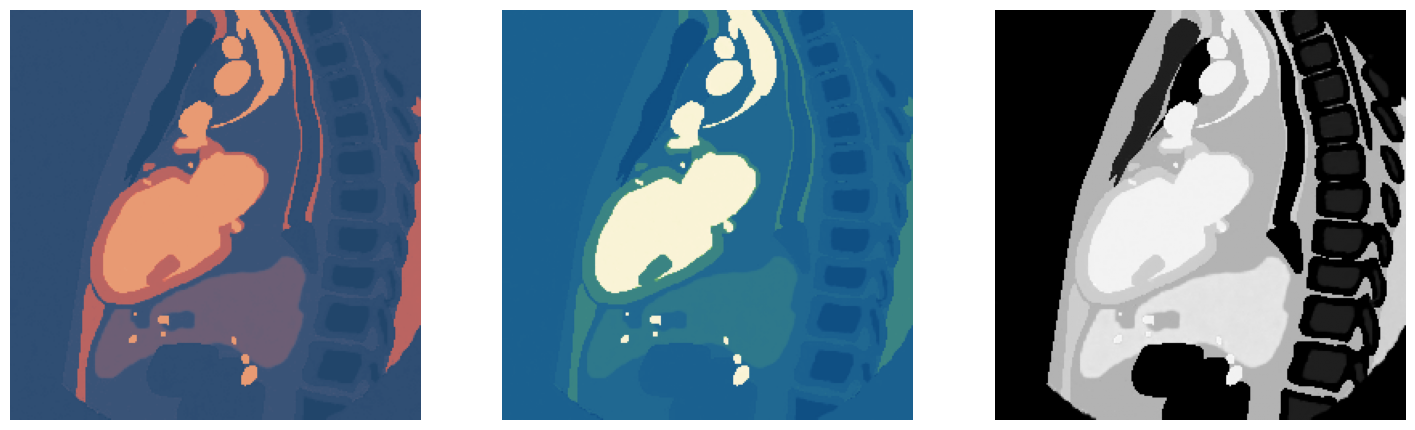

In [62]:
plt.figure(figsize=(18,6));
plt.subplot(1,3,1);
plt.imshow(T1Net,vmin=0,vmax=t1_display[1],cmap=T1cm);plt.axis('off');
plt.subplot(1,3,2);
plt.imshow(T2Net,vmin=0,vmax=t2_display[1],cmap=T2cm);plt.axis('off');
plt.subplot(1,3,3);
plt.imshow(abs(M0Net)/np.max(abs(M0Net)),vmin=0,vmax=1,cmap='gray'); plt.axis('off');
plt.show();

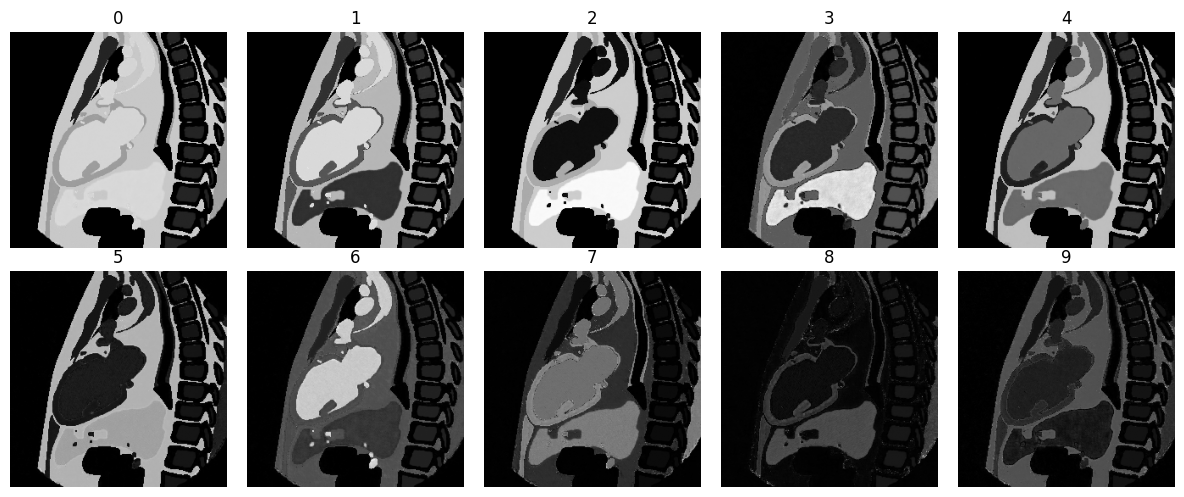

In [63]:
# Multi-contrasts images or DIP reconstructions K=10
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = np.abs(imNet[:, :, i])
    
    ax.imshow(img, vmin=0, vmax=np.max(img), cmap='gray')
    ax.axis('off')
    ax.set_title(f'{i}')

plt.tight_layout()
plt.show()

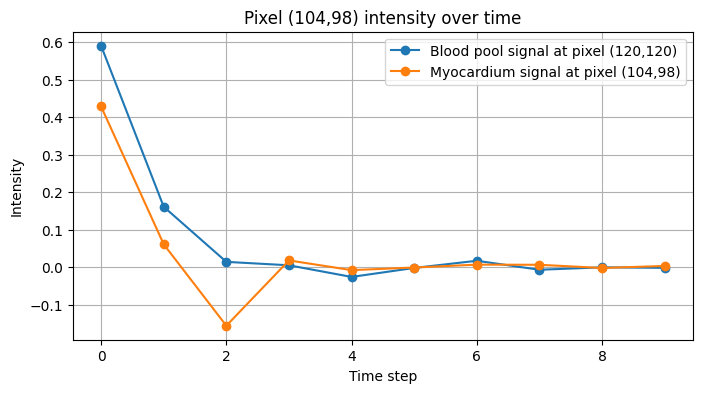

In [64]:
# Signal evolution
x = 120
y = 120
plt.figure(figsize=(8,4))
plt.plot(imNet[y, x, :], marker='o',label=f"Blood pool signal at pixel ({y},{x})")
y = 104
x = 98
plt.plot(imNet[y, x, :], marker='o',label=f"Myocardium signal at pixel ({y},{x})")
plt.title(f"Pixel ({y},{x}) intensity over time")
plt.xlabel("Time step")
plt.ylabel("Intensity")
plt.grid(True)
plt.legend()  # show labels
plt.show()

In [65]:
# Read Low-Rank maps
X = sio.loadmat(os.path.join(parent_folder, 'Tmaps_LR.mat'))
T1LR = X['T1_lowrank']
T2LR = X['T2_lowrank']
M0LR = X['M0_lowrank']


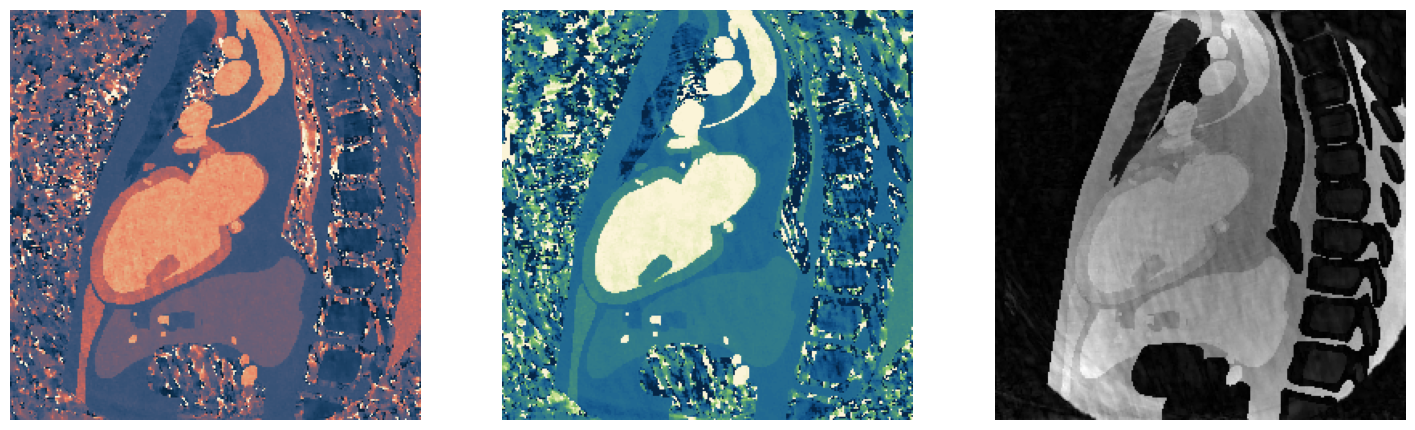

In [66]:
plt.figure(figsize=(18,6));
plt.subplot(1,3,1);
plt.imshow(T1LR,vmin=0,vmax=t1_display[1],cmap=T1cm);plt.axis('off');
plt.subplot(1,3,2);
plt.imshow(T2LR,vmin=0,vmax=t2_display[1],cmap=T2cm);plt.axis('off');
plt.subplot(1,3,3);
plt.imshow(abs(M0LR)/np.max(abs(M0LR)),vmin=0,vmax=1,cmap='gray'); plt.axis('off');
plt.show();

In [ ]:
# Read Direct Matching maps
X = sio.loadmat(os.path.join(parent_folder, 'Tmaps_DM.mat'))
T1DM = X['T1_recon']
T2DM = X['T2_recon']
M0DM = X['M0_recon']

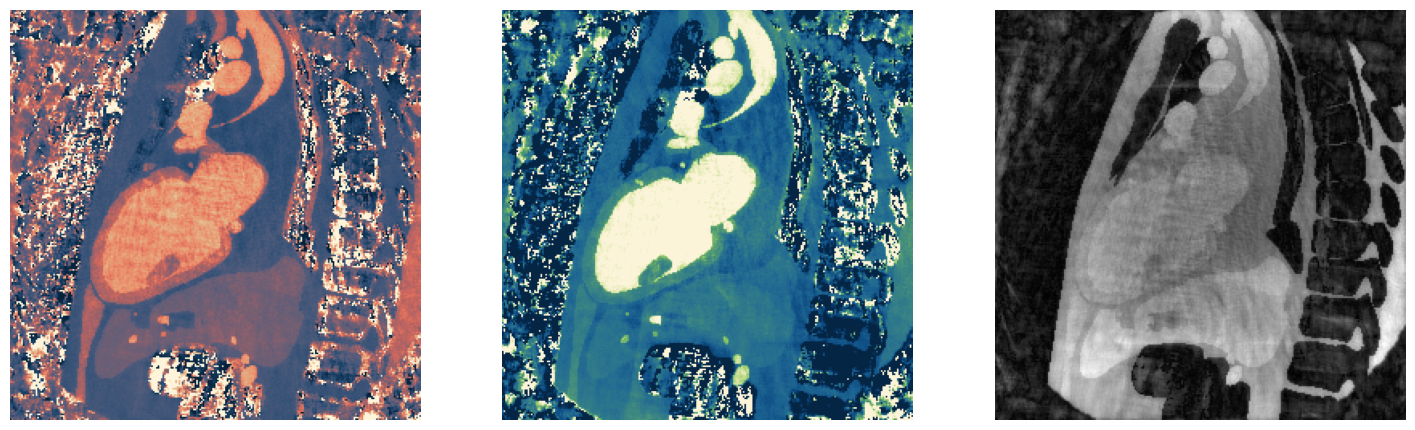

In [68]:
plt.figure(figsize=(18,6));
plt.subplot(1,3,1);
plt.imshow(T1DM,vmin=0,vmax=t1_display[1],cmap=T1cm);plt.axis('off');
plt.subplot(1,3,2);
plt.imshow(T2DM,vmin=0,vmax=t2_display[1],cmap=T2cm);plt.axis('off');
plt.subplot(1,3,3);
plt.imshow(abs(M0DM)/np.max(abs(M0DM)),vmin=0,vmax=1,cmap='gray'); plt.axis('off');
plt.show();